## Navigation

1. [Loading Section](#loading-section)
2. [Data Validation Section](#data-validation-section)
3. [Data Preparation Section](#data-preparation-section)
4. [Visualizations Section](#visualizations-section)
5. [Key Findings Section](#key-findings-section)
6. [Conclustions Section](#conclusions-section)
7. [Exports Secton](#exports-section)

## Loading Section

In [45]:
from pathlib import Path
from pprint import pprint


import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
actuals_src_dir = (
    Path.home()
    / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data/processed"
)
forecast_src_dir = (
    Path.home()
    / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data/forecasts"
)

forecast_file = "forecasted_volumes.csv"
forecast_df = pd.read_csv(forecast_src_dir / forecast_file, parse_dates=True)
print("Forecast file")
pprint(forecast_df.head())

monthly_summary_file = "monthly_summary.csv"
monthly_summary_df = pd.read_csv(
    actuals_src_dir / monthly_summary_file, parse_dates=True
)
print("Monthly summary file")
pprint(monthly_summary_df.head())

monthly_shrinkage_file = "shrinkage_monthly_summary.csv"
monthly_shrinkage_df = pd.read_csv(
    actuals_src_dir / monthly_shrinkage_file, parse_dates=True
)
print("Monthly shrinkage file")
pprint(monthly_shrinkage_df.head())

Forecast file
         date  dow_num day_of_week    month  forecast
0  2026-01-01        3    Thursday  January   3518.03
1  2026-01-02        4      Friday  January   3190.71
2  2026-01-03        5    Saturday  January   2457.71
3  2026-01-04        6      Sunday  January   1725.57
4  2026-01-05        0      Monday  January   4303.93
Monthly summary file
  year_month          month  total_volume  total_workload_hours  avg_aht  \
0    2024-01   January-2024         96698              11109.42   478.77   
1    2024-02  February-2024         88467              10194.35   476.17   
2    2024-03     March-2024         93440              10768.31   479.97   
3    2024-04     April-2024        101024              11627.29   476.16   
4    2024-05       May-2024        108407              12497.08   477.70   

   avg_volume  avg_workload_hours  month_num     trend  
0      623.86               71.67          0  95050.90  
1      610.12               70.31          1  95747.51  
2      602.84

[Back to Top](#navigation)

## Data Validation Section

In [ ]:
pprint(forecast_df.info())
print("\n")
pprint(forecast_df.describe())
print("\n")
print("Missing values: ")
pprint(forecast_df.isna().sum())
print("\nDuplicate values: ")
pprint(forecast_df.duplicated().sum())
print("\n")
pprint(f"First date: {forecast_df['date'].min()}")
pprint(f"Last date: {forecast_df['date'].max()}")
negative_forecast_rows = forecast_df.loc[forecast_df["forecast"] < 0]
pprint(f"Negative forecast rows: {len(negative_forecast_rows)}")

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         365 non-null    str    
 1   dow_num      365 non-null    int64  
 2   day_of_week  365 non-null    str    
 3   month        365 non-null    str    
 4   forecast     365 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 14.4 KB
None


       dow_num     forecast
count    365.0   365.000000
mean       3.0  3554.509973
std        2.0   921.438676
min        0.0  1492.350000
25%        1.0  2959.700000
50%        3.0  3736.340000
75%        5.0  4265.360000
max        6.0  5265.640000


Missing values: 
date           0
dow_num        0
day_of_week    0
month          0
forecast       0
dtype: int64

Duplicate values: 
np.int64(0)


'First date: 2026-01-01'
'Last date: 2026-12-31'
'Negative forecast rows: 0'


In [48]:
pprint(monthly_summary_df.info())
print("\n")
pprint(monthly_summary_df.describe())
print("\n")
print("Missing values: ")
pprint(monthly_summary_df.isna().sum())
print("\nDuplicate values: ")
pprint(monthly_summary_df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year_month            24 non-null     str    
 1   month                 24 non-null     str    
 2   total_volume          24 non-null     int64  
 3   total_workload_hours  24 non-null     float64
 4   avg_aht               24 non-null     float64
 5   avg_volume            24 non-null     float64
 6   avg_workload_hours    24 non-null     float64
 7   month_num             24 non-null     int64  
 8   trend                 24 non-null     float64
dtypes: float64(5), int64(2), str(2)
memory usage: 1.8 KB
None


        total_volume  total_workload_hours     avg_aht  avg_volume  \
count      24.000000             24.000000   24.000000   24.000000   
mean   103061.916667          11892.701250  478.877917  676.632917   
std     11527.059993           1334.039244    2.148468   72.068494   
min

In [49]:
pprint(monthly_shrinkage_df.info())
print("\n")
pprint(monthly_shrinkage_df.describe())
print("\n")
print("Missing values: ")
pprint(monthly_shrinkage_df.isna().sum())
print("\nDuplicate values: ")
pprint(monthly_shrinkage_df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year_month     24 non-null     str    
 1   shrinkage_pct  24 non-null     float64
dtypes: float64(1), str(1)
memory usage: 516.0 bytes
None


       shrinkage_pct
count      24.000000
mean        0.305392
std         0.008249
min         0.296300
25%         0.300175
50%         0.302650
75%         0.308750
max         0.328800


Missing values: 
year_month       0
shrinkage_pct    0
dtype: int64

Duplicate values: 
np.int64(0)


[Back to Top](#navigation)

## Data Preparation Section

In [ ]:
monthly_aht = (
    monthly_summary_df.assign(month=lambda df: df["month"].str.split("-").str[0])
    .groupby("month", as_index=False)["avg_aht"]
    .mean()
    .round(2)
)
pprint(monthly_aht.head(12))

        month  avg_aht
0       April   480.02
1      August   477.78
2    December   477.60
3    February   476.68
4     January   479.56
5        July   478.42
6        June   480.49
7       March   477.47
8         May   478.17
9    November   480.75
10    October   479.32
11  September   480.29


In [ ]:
monthly_shrinkage = (
    monthly_shrinkage_df.assign(
        month=lambda df: pd.to_datetime(
            df["year_month"], format="%Y-%m"
        ).dt.month_name()
    )
    .groupby("month", as_index=False)["shrinkage_pct"]
    .mean()
    .round(4)
)
pprint(monthly_shrinkage.head(12))

        month  shrinkage_pct
0       April         0.3012
1      August         0.3083
2    December         0.3282
3    February         0.3002
4     January         0.3016
5        July         0.3103
6        June         0.3100
7       March         0.3032
8         May         0.2989
9    November         0.3035
10    October         0.2992
11  September         0.3002


In [ ]:
shift_hrs_assumption = 8
column_name_mapping = {
    "avg_aht": "aht_assumption",
    "shrinkage_pct": "shrinkage_assumption",
}
workload_df = (
    pd.merge(
        forecast_df,
        monthly_aht,
        on="month",
    )
    .merge(monthly_shrinkage, on="month")
    .rename(columns=column_name_mapping)
    .assign(
        date=lambda df: pd.to_datetime(df["date"]),
        workload_hrs=lambda df: ((df["forecast"] * df["aht_assumption"]) / 3600).round(
            2
        ),
        required_fte_raw=lambda df: (df["workload_hrs"] / shift_hrs_assumption).round(
            2
        ),
        required_fte_shrinkage_adjusted=lambda df: (
            df["required_fte_raw"] / (1 - df["shrinkage_assumption"])
        ).round(2),
        fte_delta=lambda df: (
            df["required_fte_shrinkage_adjusted"] - df["required_fte_raw"]
        ).round(2),
    )
)
pprint(workload_df.head())

        date  dow_num day_of_week    month  forecast  aht_assumption  \
0 2026-01-01        3    Thursday  January   3518.03          479.56   
1 2026-01-02        4      Friday  January   3190.71          479.56   
2 2026-01-03        5    Saturday  January   2457.71          479.56   
3 2026-01-04        6      Sunday  January   1725.57          479.56   
4 2026-01-05        0      Monday  January   4303.93          479.56   

   shrinkage_assumption  workload_hrs  required_fte_raw  \
0                0.3016        468.64             58.58   
1                0.3016        425.04             53.13   
2                0.3016        327.39             40.92   
3                0.3016        229.87             28.73   
4                0.3016        573.33             71.67   

   required_fte_shrinkage_adjusted  fte_delta  
0                            83.88      25.30  
1                            76.07      22.94  
2                            58.59      17.67  
3                   

In [ ]:
monthly_forecasted_summary = (
    workload_df.assign(month_num=lambda df: df["date"].dt.month)
    .groupby("month_num", as_index=False)
    .agg(
        month=("month", "first"),
        total_volume=("forecast", "sum"),
        average_volume=("forecast", lambda s: s.mean().round(2)),
        total_workload_hrs=("workload_hrs", "sum"),
        average_workload_hrs=("workload_hrs", lambda s: s.mean().round(2)),
        total_fte_requirement_raw=("required_fte_raw", "sum"),
        average_required_fte_raw=("required_fte_raw", lambda s: s.mean().round(2)),
        total_fte_requirement_shrinkage_adjusted=(
            "required_fte_shrinkage_adjusted",
            "sum",
        ),
        average_required_fte_shrinkage_adjusted=(
            "required_fte_shrinkage_adjusted",
            lambda s: s.mean().round(2),
        ),
        total_fte_delta=("fte_delta", "sum"),
        average_fte_delta=("fte_delta", lambda s: s.mean().round(2)),
    )
)
pprint(monthly_forecasted_summary.head(13))

    month_num      month  total_volume  average_volume  total_workload_hrs  \
0           1    January     101420.07         3271.62            13510.28   
1           2   February      91173.42         3256.19            12072.36   
2           3      March     103536.14         3339.88            13732.07   
3           4      April     107612.44         3587.08            14348.92   
4           5        May     113350.48         3656.47            15055.80   
5           6       June     113151.00         3771.70            15102.19   
6           7       July      96462.33         3111.69            12819.32   
7           8     August      93528.69         3017.05            12412.80   
8           9  September     109777.30         3659.24            14645.84   
9          10    October     118060.54         3808.40            15719.09   
10         11   November     116129.12         3870.97            15508.08   
11         12   December     133194.61         4296.60          

In [ ]:
weekly_forecasted_summary = (
    workload_df.assign(
        week_of_year=lambda df: df["date"].dt.isocalendar().week,
    )
    .groupby("week_of_year", as_index=False)
    .agg(
        total_volume=("forecast", "sum"),
        average_volume=("forecast", lambda s: s.mean().round(2)),
        total_workload_hrs=("workload_hrs", "sum"),
        average_workload_hrs=("workload_hrs", lambda s: s.mean().round(2)),
        total_fte_requirement_raw=("required_fte_raw", "sum"),
        average_required_fte_raw=("required_fte_raw", lambda s: s.mean().round(2)),
        total_fte_requirement_shrinkage_adjusted=(
            "required_fte_shrinkage_adjusted",
            "sum",
        ),
        average_required_fte_shrinkage_adjusted=(
            "required_fte_shrinkage_adjusted",
            lambda s: s.mean().round(2),
        ),
        total_fte_delta=("fte_delta", "sum"),
        average_fte_delta=("fte_delta", lambda s: s.mean().round(2)),
    )
)
pprint(weekly_forecasted_summary.head())
pprint(weekly_forecasted_summary.tail())

   week_of_year  total_volume  average_volume  total_workload_hrs  \
0             1      10892.02         2723.00             1450.94   
1             2      23042.41         3291.77             3069.50   
2             3      23057.88         3293.98             3071.57   
3             4      23073.35         3296.19             3073.62   
4             5      23041.40         3291.63             3068.03   

   average_workload_hrs  total_fte_requirement_raw  average_required_fte_raw  \
0                362.74                     181.36                     45.34   
1                438.50                     383.70                     54.81   
2                438.80                     383.94                     54.85   
3                439.09                     384.20                     54.89   
4                438.29                     383.51                     54.79   

   total_fte_requirement_shrinkage_adjusted  \
0                                    259.68   
1         

In [ ]:
weekday_forecasted_summary = workload_df.groupby("day_of_week", as_index=False).agg(
    total_volume=("forecast", "sum"),
    average_volume=("forecast", lambda s: s.mean().round(2)),
    total_workload_hrs=("workload_hrs", "sum"),
    average_workload_hrs=("workload_hrs", lambda s: s.mean().round(2)),
    total_fte_requirement_raw=("required_fte_raw", "sum"),
    average_required_fte_raw=("required_fte_raw", lambda s: s.mean().round(2)),
    total_fte_requirement_shrinkage_adjusted=("required_fte_shrinkage_adjusted", "sum"),
    average_required_fte_shrinkage_adjusted=(
        "required_fte_shrinkage_adjusted",
        lambda s: s.mean().round(2),
    ),
    total_fte_delta=("fte_delta", "sum"),
    average_fte_delta=("fte_delta", lambda s: s.mean().round(2)),
)
pprint(weekday_forecasted_summary.head(8))

  day_of_week  total_volume  average_volume  total_workload_hrs  \
0      Friday     179343.42         3448.91            23858.38   
1      Monday     237222.35         4561.97            31559.32   
2    Saturday     141186.38         2715.12            18782.31   
3      Sunday     103182.79         1984.28            13727.03   
4    Thursday     200682.84         3786.47            26697.40   
5     Tuesday     226943.37         4364.30            30190.61   
6   Wednesday     208834.99         4016.06            27782.19   

   average_workload_hrs  total_fte_requirement_raw  average_required_fte_raw  \
0                458.81                    2982.30                     57.35   
1                606.91                    3944.90                     75.86   
2                361.20                    2347.78                     45.15   
3                263.98                    1715.86                     33.00   
4                503.72                    3337.17             

[Back to Top](#navigation)

## Visualizations Section

In [ ]:
title_font = {"fontsize": 10, "fontweight": "bold"}
label_font = {"fontweight": "bold"}

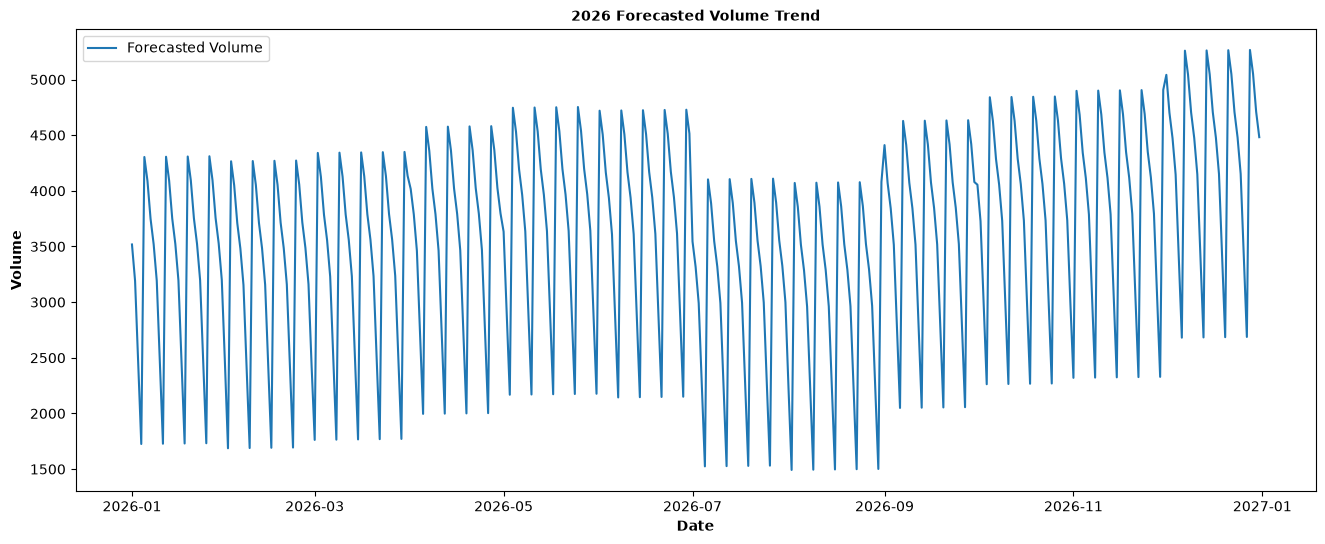

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(workload_df["date"], workload_df["forecast"], label="Forecasted Volume")
ax.set_title("2026 Forecasted Volume Trend", fontdict=title_font)
ax.set_xlabel("Date", fontdict=label_font)
ax.set_ylabel("Volume", fontdict=label_font)
ax.legend()
plt.show()

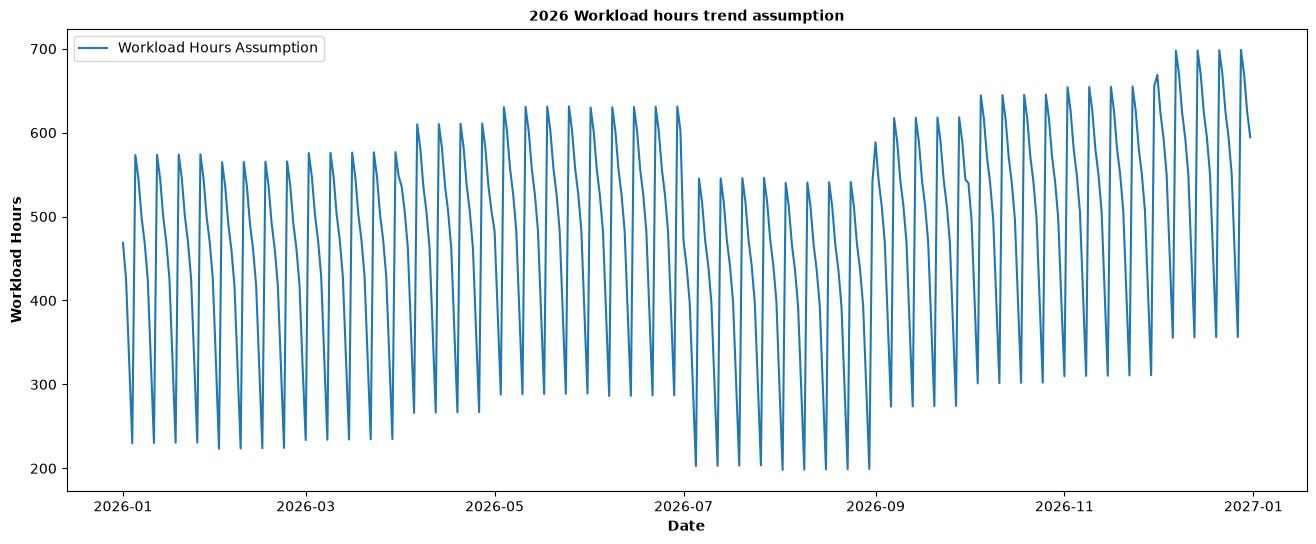

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    workload_df["date"], workload_df["workload_hrs"], label="Workload Hours Assumption"
)
ax.set_title("2026 Workload hours trend assumption", fontdict=title_font)
ax.set_xlabel("Date", fontdict=label_font)
ax.set_ylabel("Workload Hours", fontdict=label_font)
ax.legend()
plt.show()

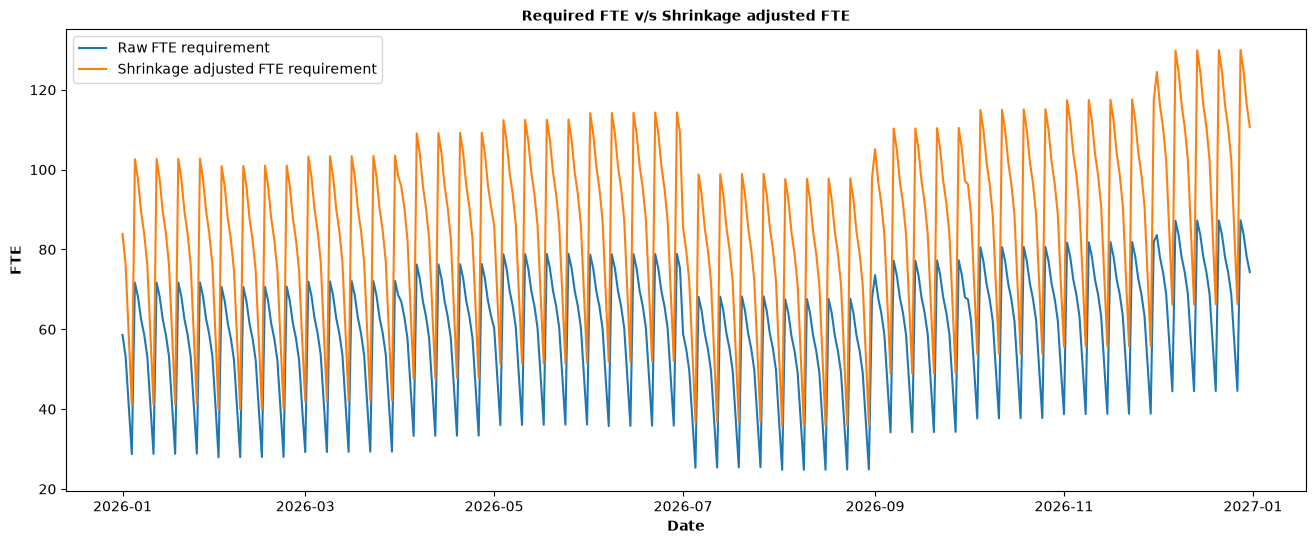

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    workload_df["date"], workload_df["required_fte_raw"], label="Raw FTE requirement"
)
ax.plot(
    workload_df["date"],
    workload_df["required_fte_shrinkage_adjusted"],
    label="Shrinkage adjusted FTE requirement",
)
ax.set_title("Required FTE v/s Shrinkage adjusted FTE", fontdict=title_font)
ax.set_xlabel("Date", fontdict=label_font)
ax.set_ylabel("FTE", fontdict=label_font)
ax.legend()
plt.show()

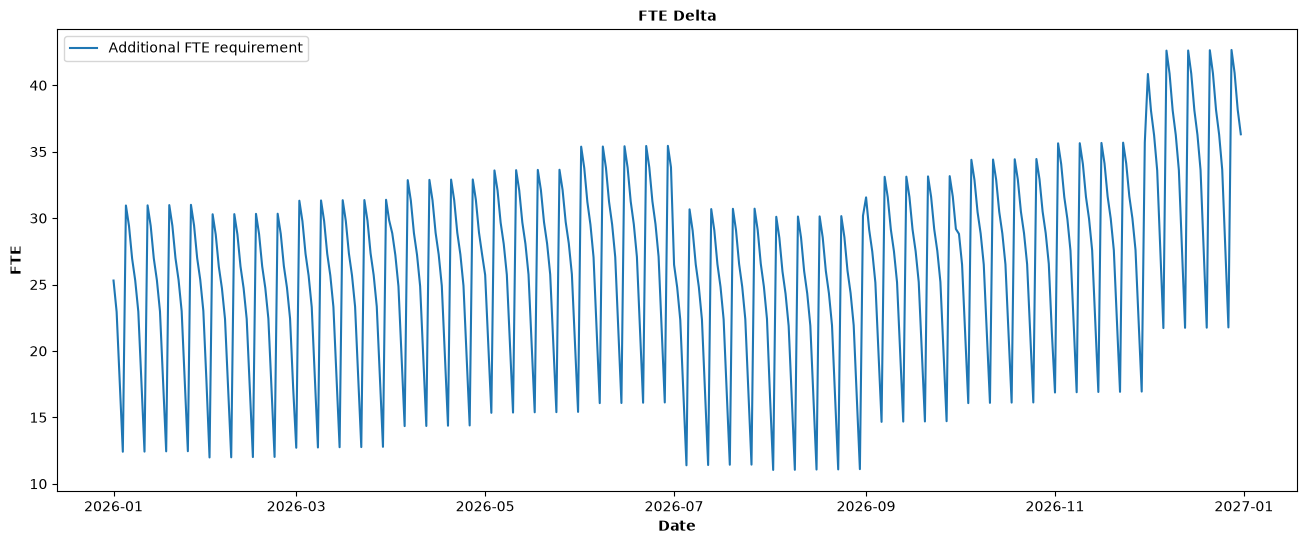

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    workload_df["date"], workload_df["fte_delta"], label="Additional FTE requirement"
)
ax.set_title("FTE Delta", fontdict=title_font)
ax.set_xlabel("Date", fontdict=label_font)
ax.set_ylabel("FTE", fontdict=label_font)
ax.legend()
plt.show()

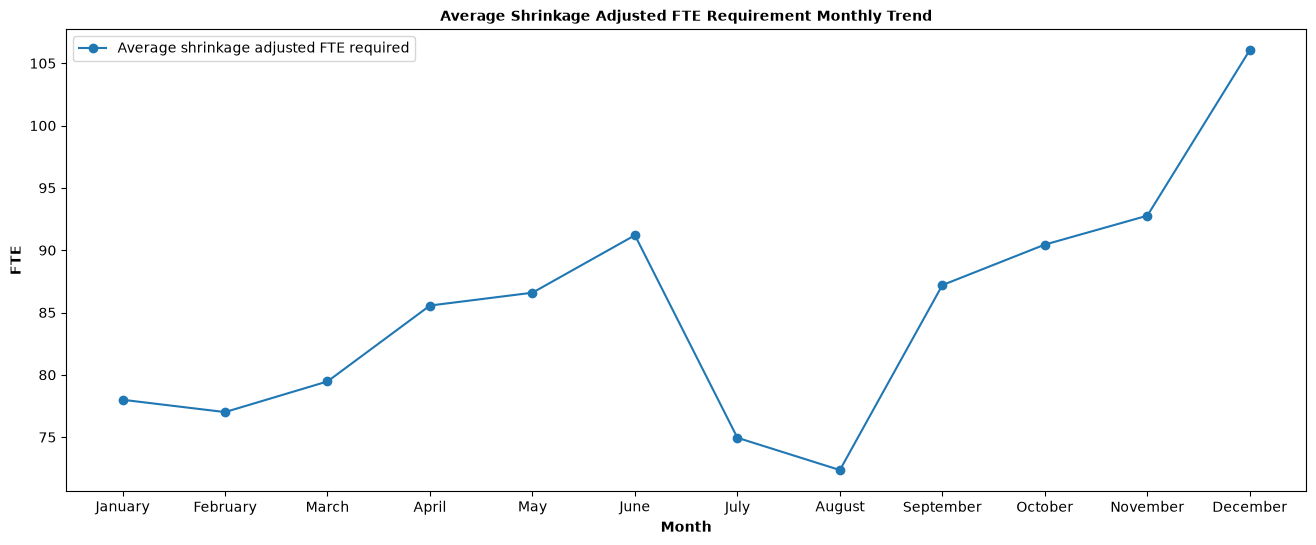

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    monthly_forecasted_summary["month"],
    monthly_forecasted_summary["average_required_fte_shrinkage_adjusted"],
    label="Average shrinkage adjusted FTE required",
    marker="o",
)
ax.set_title(
    "Average Shrinkage Adjusted FTE Requirement Monthly Trend", fontdict=title_font
)
ax.set_xlabel("Month", fontdict=label_font)
ax.set_ylabel("FTE", fontdict=label_font)
ax.legend()
plt.show()

[Back to Top](#navigation)

## Key Findings section

In [ ]:
print(f"Average volume per day: {workload_df['forecast'].mean().round(2)}")
print(f"Peak volume per day: {workload_df['forecast'].max().round(2)}")
print(f"Lowest volume per day: {workload_df['forecast'].min().round(2)}")
print(f"Average workload hours per day: {workload_df['workload_hrs'].mean().round(2)}")
print(f"Peak workload hours per day: {workload_df['workload_hrs'].max().round(2)}")
print(f"Lowest workload hours per day: {workload_df['workload_hrs'].min().round(2)}")
print(
    f"Average raw FTE requirement per day: {workload_df['required_fte_raw'].mean().round(2)}"
)
print(
    f"Peak raw FTE requirement per day: {workload_df['required_fte_raw'].max().round(2)}"
)
print(
    f"Lowest raw FTE requirement per day: {workload_df['required_fte_raw'].min().round(2)}"
)
print(
    f"Average shrinkage adjusted FTE requirement per day: {workload_df['required_fte_shrinkage_adjusted'].mean().round(2)}"
)
print(
    f"Peak shrinkage adjusted FTE requirement per day: {workload_df['required_fte_shrinkage_adjusted'].max().round(2)}"
)
print(
    f"Lowest shrinkage adjusted FTE requirement per day: {workload_df['required_fte_shrinkage_adjusted'].min().round(2)}"
)
print(
    f"Average additional FTE required per day: {workload_df['fte_delta'].mean().round(2)}"
)
print(
    f"Peak additional FTE required per day: {workload_df['fte_delta'].max().round(2)}"
)
print(
    f"Lowest additional FTE required per day: {workload_df['fte_delta'].min().round(2)}"
)


Average volume per day: 3554.51
Peak volume per day: 5265.64
Lowest volume per day: 1492.35
Average workload hours per day: 472.87
Peak workload hours per day: 698.57
Lowest workload hours per day: 198.06
Average raw FTE requirement per day: 59.11
Peak raw FTE requirement per day: 87.32
Lowest raw FTE requirement per day: 24.76
Average shrinkage adjusted FTE requirement per day: 85.16
Peak shrinkage adjusted FTE requirement per day: 129.98
Lowest shrinkage adjusted FTE requirement per day: 35.8
Average additional FTE required per day: 26.05
Peak additional FTE required per day: 42.66
Lowest additional FTE required per day: 11.04


In [ ]:
print(
    f"Which month requires the highest staffing: {monthly_forecasted_summary.nlargest(1, columns=['average_required_fte_shrinkage_adjusted'], keep='first')['month'].item()}"
)
print(
    f"Which month requires the lowest staffing: {monthly_forecasted_summary.nsmallest(1, columns=['average_required_fte_shrinkage_adjusted'], keep='first')['month'].item()}"
)
print(
    f"What is the busiest day: {weekday_forecasted_summary.nlargest(1, columns=['average_volume'], keep='first')['day_of_week'].item()}"
)
print(
    f"What is the busiest week of the year: {weekly_forecasted_summary.nlargest(1, columns=['average_volume'], keep='first')['week_of_year'].item()}"
)
ranking_by_fte_requirement = monthly_forecasted_summary.assign(
    ranking=lambda df: df["average_required_fte_shrinkage_adjusted"].rank(
        ascending=False, method="dense"
    )
).sort_values(by="ranking")
pprint(
    f"Month ranking by shrinkage adjusted fte requirement: {ranking_by_fte_requirement[['month', 'ranking', 'average_required_fte_shrinkage_adjusted']]}"
)

Which month requires the highest staffing: December
Which month requires the lowest staffing: August
What is the busiest day: Monday
What is the busiest week of the year: 53
('Month ranking by shrinkage adjusted fte requirement:         month  ranking  '
 'average_required_fte_shrinkage_adjusted\n'
 '11   December      1.0                                   106.06\n'
 '10   November      2.0                                    92.77\n'
 '5        June      3.0                                    91.20\n'
 '9     October      4.0                                    90.45\n'
 '8   September      5.0                                    87.20\n'
 '4         May      6.0                                    86.59\n'
 '3       April      7.0                                    85.56\n'
 '2       March      8.0                                    79.47\n'
 '0     January      9.0                                    78.00\n'
 '1    February     10.0                                    77.01\n'
 '6       

[Back to Top](#navigation)

## Conclusions Section

* Forecasted workload demand for 2026 is expected to average **3554.51 transactions per day**, with peak demand reaching **5265.64 transactions** and the lowest demand observed at **1492.35 transactions**.

* Converting forecasted demand into operational workload resulted in an average daily workload requirement of **472.87 hours**, with a maximum daily workload of **698.57 hours**.

* Workforce requirements before shrinkage adjustments averaged **59.11 FTEs**, ranging from **24.76 FTEs** to **87.32 FTEs** throughout the forecast horizon.

* After incorporating historical shrinkage assumptions, the average staffing requirement increased to **85.16 FTEs**, with peak staffing demand reaching **129.98 FTEs**.

* Shrinkage had a measurable impact on workforce requirements, increasing staffing needs by an average of **26.05 FTEs** compared to raw staffing calculations.

* Capacity requirements exhibited clear seasonal patterns throughout the year, with the highest staffing demand occurring during **December** and the lowest demand observed during **February**.

* The months requiring the greatest workforce capacity were **December, November and June**, indicating periods where workforce planners should prioritize staffing readiness and resource allocation.

* The forecasted workforce requirements demonstrate that staffing demand is not constant throughout the year and is influenced by both workload seasonality and operational shrinkage factors.

* This analysis establishes a data-driven estimate of workforce requirements for 2026 by translating forecasted demand into staffing needs using historical AHT and shrinkage assumptions.

* The outputs generated during this phase provide the foundation for the next stage of the project, where workforce planning scenarios can be evaluated against forecasted staffing requirements to assess coverage, capacity risk, and potential hiring needs.

* Historical shrinkage assumptions increased workforce requirements by approximately 26 FTEs on average, demonstrating the importance of accounting for non-productive time when estimating staffing needs.


[Back to Top](#navigation)

## Exports Section

In [ ]:
output_dir = (
    Path.home()
    / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data/capacity"
)
output_dir.mkdir(parents=True, exist_ok=True)

daily_requirements_file = "daily_capacity_requirements.csv"
workload_df.to_csv(output_dir / daily_requirements_file, index=False)

monthly_summary_file = "monthly_capacity_requirements_summary.csv"
monthly_forecasted_summary.to_csv(output_dir / monthly_summary_file, index=False)

[Back to Top](#navigation)